# Tuning hyperparameters

In [1]:
from Modules.read_data import read_data

(
    DK1_train, 
    DK1_test, 
    DK2_train, 
    DK2_test,
    DK1_train_weather, 
    DK1_test_weather, 
    DK2_train_weather, 
    DK2_test_weather
    ) = read_data("combined_data_cleaned_v4.csv")

ModuleNotFoundError: No module named 'Modules'

## Import model and choose parameter search grid

In [2]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import numpy as np
# Import model library. E.g.:
# from sklearn.svm import SVR
from sklearn.svm import SVR

# Initialize model:
model = SVR()

# Keep at least one number in each list to avoid wrong calculation of total combinations
# If a parameter is not relevant just set a 0 in the list
param_grid = {
    "C": [0.1, 1, 10],
    "epsilon": [0.01, 0.1, 0.2],
    "degree": [0],                  # only for 'poly'
    "gamma": ["scale"],             # "scale", "auto", 0.001, 0.01, 0.1
    "coef0": [0.0],             # only for 'poly'
    "kernel": ["rbf"]
}
num_combinations = np.prod([len(v) for v in param_grid.values()])
print(f"Total number of combinations to test: {num_combinations}")


Total number of combinations to test: 9


## Choose validation setup


**Setup 1**

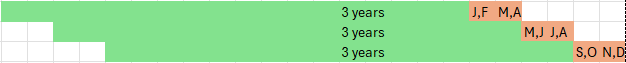

For this setup, val_start in the first fold is fixed at 2024-01-01 00:00:00 and train_end the hour before that (2023-12-31 23:00:00). train_start, val_end and remaining fold values are computed using train_window, predict_horizon and stride.

**Setup 2**



For this setup, val_end in the first fold is fixed at 2024-12-31 23:00:00. train_start, train_end and val_start are computed using train_window and predict_horizon. There is only one fold, so stride has no function.

Write the desired setup number as "split_setup" in the hyper_param_split() function below.

## Find best parameters

### Hyperparameter search for DK1:

Remember to give the right path to save the csv with results!

In [ ]:
from Modules.Cross_Validation_runner import run_cross_validation
import itertools
import pandas as pd
import os

print(f"Total number of combinations to test: {num_combinations}")

param_names = list(param_grid.keys())
param_values = list(param_grid.values())
all_combinations = list(itertools.product(*param_values))

results = []
for comb_number, combination in enumerate(all_combinations, start=1):
    params = dict(zip(param_names, combination))

    print(f"\nCombination {comb_number}/{num_combinations}: {params}")

    model.set_params(**params)
    combination_results = run_cross_validation(
        model = model,
        dataset = DK1_train,
        split_setup = 2,
        train_window = 3 * 8760,        # 8760 hours = 1 year
        predict_horizon = 17 * 168,     # 168 hours = 1 week
        stride = 17 * 168,              
        use_scaler = True,              # Set to True for models that needs feature scaling
        print_fold_results = False,     # Print weekly SMAPE values for each fold in each combination?
        plot = False,                   # Plot daily SMAPE values for the entire predict_horizon for each combination? 
    )
    row = {**params, "avg_smape": combination_results["overall_avg_weekly_smape"]}
    results.append(row)

# Save the search results as a CSV file in chosen folder path:
results_df = pd.DataFrame(results).sort_values("avg_smape")
folder = r"C:\Users\n_and\OneDrive\Delt skrivebord\Data Science\Speciale\Energinet\Delte scripts\Speciale_Kode\Shallow learners\SVM"
base_filename = "DK1_hyperparameter_results.csv"
filename = os.path.join(folder, base_filename)

# adds a number to the filename if a file with same name already exists:
counter = 1     
while os.path.exists(filename):
    filename = os.path.join(folder, f"DK1_hyperparameter_results_{counter}.csv")
    counter += 1
results_df.to_csv(filename, index=False)

print(f"\nResults saved to: {filename}")
# print(results_df.to_string(index=False))


Total number of combinations to test: 9

Combination 1/9: {'C': 0.1, 'epsilon': 0.01, 'degree': 0, 'gamma': 'scale', 'coef0': 0.0, 'kernel': 'rbf'}
Number of folds: 1
Fold 1: Train from 2021-09-05 00:00:00 to 2024-09-03 23:00:00,
        Validation from 2024-09-04 00:00:00 to 2024-12-31 23:00:00

Average SMAPE across all weeks in all folds: 58.686

Combination 2/9: {'C': 0.1, 'epsilon': 0.1, 'degree': 0, 'gamma': 'scale', 'coef0': 0.0, 'kernel': 'rbf'}
Number of folds: 1
Fold 1: Train from 2021-09-05 00:00:00 to 2024-09-03 23:00:00,
        Validation from 2024-09-04 00:00:00 to 2024-12-31 23:00:00


KeyboardInterrupt: 

### Hyperparameter search for DK2:

Remember to give the right path to save the csv with resutls!

In [ ]:
from Modules.Cross_Validation_runner import run_cross_validation
import itertools
import pandas as pd
import os

print(f"Total number of combinations to test: {num_combinations}")

param_names = list(param_grid.keys())
param_values = list(param_grid.values())
all_combinations = list(itertools.product(*param_values))

results = []
for comb_number, combination in enumerate(all_combinations, start=1):
    params = dict(zip(param_names, combination))

    print(f"\nCombination {comb_number}/{num_combinations}: {params}")

    model.set_params(**params)
    combination_results = run_cross_validation(
        model = model,
        dataset = DK2_train,
        split_setup = 2,
        train_window = 3 * 8760,        # 8760 hours = 1 year
        predict_horizon = 17 * 168,     # 168 hours = 1 week
        stride = 17 * 168,              
        use_scaler = True,              # Set to True for models that needs feature scaling
        print_fold_results = False,     # Print weekly results for each fold in each combination?
        plot = False,                   # Plot daily SMAPE values for the entire predict_horizon for each combination? 
    )
    row = {**params, "avg_smape": combination_results["overall_avg_weekly_smape"]}
    results.append(row)

# Save the search results as a CSV file in chosen folder path:
results_df = pd.DataFrame(results).sort_values("avg_smape")
folder = r"C:\Users\n_and\OneDrive\Delt skrivebord\Data Science\Speciale\Energinet\Delte scripts\Speciale_Kode\Shallow learners\SVM"
base_filename = "DK2_hyperparameter_results.csv"
filename = os.path.join(folder, base_filename)

# adds a number to the filename if a file with same name already exists:
counter = 1     
while os.path.exists(filename):
    filename = os.path.join(folder, f"DK2_hyperparameter_results_{counter}.csv")
    counter += 1
results_df.to_csv(filename, index=False)

print(f"\nResults saved to: {filename}")
# print(results_df.to_string(index=False))
